<a href="https://colab.research.google.com/github/Mansehaj-Singh/Drone-Orientation-Estimation/blob/main/IMU_Gyro_Slow.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
from google.colab import files
uploaded = files.upload()

Saving AP1.xlsx to AP1.xlsx
Saving AP2.xlsx to AP2.xlsx
Saving Qs_slow.xlsx to Qs_slow.xlsx
Saving SH1.xlsx to SH1.xlsx
Saving SH2.xlsx to SH2.xlsx
Saving XS1.xlsx to XS1.xlsx
Saving XS2.xlsx to XS2.xlsx


Total sequences: 24987
Static sequences: 17459
Dynamic sequences: 7528
Train sequences: (17990, 200, 6) (17990, 4)
Val sequences: (1999, 200, 6) (1999, 4)
Test sequences: (4998, 200, 6) (4998, 4)
Epoch 001 | train loss: 0.568901 | val loss: 0.620120
Epoch 002 | train loss: 0.474406 | val loss: 0.465028
Epoch 003 | train loss: 0.448553 | val loss: 0.608661
Epoch 004 | train loss: 0.435063 | val loss: 0.655209
Epoch 005 | train loss: 0.417045 | val loss: 0.406089
Epoch 006 | train loss: 0.410360 | val loss: 0.447375
Epoch 007 | train loss: 0.405632 | val loss: 0.397853
Epoch 008 | train loss: 0.404630 | val loss: 0.407981
Epoch 009 | train loss: 0.401138 | val loss: 0.396030
Epoch 010 | train loss: 0.400017 | val loss: 0.387198
Epoch 011 | train loss: 0.398415 | val loss: 0.395640
Epoch 012 | train loss: 0.403937 | val loss: 0.387277
Epoch 013 | train loss: 0.400125 | val loss: 0.399676
Epoch 014 | train loss: 0.390865 | val loss: 0.374100
Epoch 015 | train loss: 0.376386 | val loss: 0.3

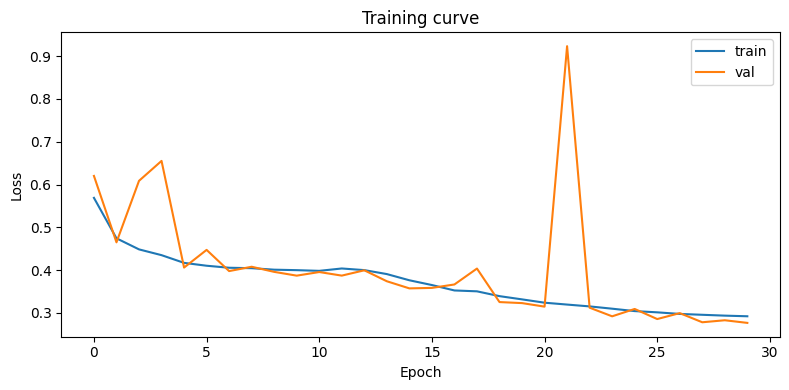


Saved files in ./outputs/


In [2]:
import os
import math
import json
import random
from dataclasses import dataclass

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader

from sklearn.model_selection import train_test_split


# =========================================================
# CONFIG
# =========================================================
SENSOR_FILES = ["XS1.xlsx", "XS2.xlsx", "AP1.xlsx", "AP2.xlsx", "SH1.xlsx", "SH2.xlsx"]
QUAT_FILE = "Qs_slow.xlsx"

SEQ_LEN = 200
MOTION_THRESHOLD = 0.10  # gyro magnitude threshold used to separate static/dynamic windows
TEST_SIZE = 0.20
VAL_SIZE = 0.10
RANDOM_STATE = 42

BATCH_SIZE = 64
EPOCHS = 30
LR = 1e-3
WEIGHT_DECAY = 1e-4
PATIENCE = 8

DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
torch.manual_seed(RANDOM_STATE)
np.random.seed(RANDOM_STATE)
random.seed(RANDOM_STATE)

# =========================================================
# HELPERS
# =========================================================
def ensure_files_exist(required_files):
    missing = [f for f in required_files if not os.path.exists(f)]
    if missing and files is not None:
        print("Upload the missing files:", missing)
        uploaded = files.upload()
        print("Uploaded:", list(uploaded.keys()))
    still_missing = [f for f in required_files if not os.path.exists(f)]
    if still_missing:
        raise FileNotFoundError(
            "Missing required files: {}\n"
            "Put them in the Colab working directory or upload them.".format(still_missing)
        )

def canonicalize_quaternions(q):
    q = np.asarray(q, dtype=np.float32)
    q = q / np.linalg.norm(q, axis=1, keepdims=True).clip(min=1e-8)
    # make qw non-negative to remove sign ambiguity for component-wise RMSE
    sign = np.where(q[:, :1] < 0, -1.0, 1.0).astype(np.float32)
    return q * sign

def read_sensor_excel(path):
    df = pd.read_excel(path)
    if df.shape[1] < 7:
        raise ValueError(f"{path} has only {df.shape[1]} columns; expected at least 7.")
    # The first 14 columns in your files are assumed to be:
    # time, ax, ay, az, gx, gy, gz, mx, my, mz, ox, oy, oz, ow
    # Only the first 7 are required for this pipeline.
    cols = df.columns[:14].tolist()
    df = df.loc[:, cols].copy()
    if df.shape[1] >= 14:
        df.columns = ["time", "ax", "ay", "az", "gx", "gy", "gz", "mx", "my", "mz", "ox", "oy", "oz", "ow"]
    else:
        # fallback if file has fewer columns
        needed = ["time", "ax", "ay", "az", "gx", "gy", "gz"]
        df.columns = needed[:df.shape[1]]
    return df

def build_windows(X_raw, y_raw, motion_flags, seq_len=200):
    """
    X_raw: [N, C]
    y_raw: [N, 4]
    motion_flags: [N]
    Returns:
      X_seq: [M, seq_len, C]
      y_seq: [M, 4]  target is the quaternion at the last time step
      m_seq: [M]     0 = static, 1 = dynamic (based on mean motion in window)
    """
    X_raw = np.asarray(X_raw, dtype=np.float32)
    y_raw = np.asarray(y_raw, dtype=np.float32)
    motion_flags = np.asarray(motion_flags, dtype=np.int64)

    n = len(X_raw)
    if n < seq_len:
        return (
            np.empty((0, seq_len, X_raw.shape[1]), dtype=np.float32),
            np.empty((0, 4), dtype=np.float32),
            np.empty((0,), dtype=np.int64),
        )

    X_seq, y_seq, m_seq = [], [], []
    for i in range(n - seq_len + 1):
        j = i + seq_len
        X_seq.append(X_raw[i:j])
        y_seq.append(y_raw[j - 1])
        m_seq.append(1 if np.mean(motion_flags[i:j]) > 0.5 else 0)

    return (
        np.asarray(X_seq, dtype=np.float32),
        np.asarray(y_seq, dtype=np.float32),
        np.asarray(m_seq, dtype=np.int64),
    )

def split_subset(X, y, test_size=0.2, seed=42):
    if len(X) < 3:
        return X, X[:0], y, y[:0]
    X_tr, X_te, y_tr, y_te = train_test_split(
        X, y, test_size=test_size, random_state=seed, shuffle=True
    )
    return X_tr, X_te, y_tr, y_te

def standardize_train_test(X_train, X_test):
    scaler_mean = X_train.reshape(-1, X_train.shape[-1]).mean(axis=0)
    scaler_std = X_train.reshape(-1, X_train.shape[-1]).std(axis=0)
    scaler_std = np.where(scaler_std < 1e-8, 1.0, scaler_std)

    X_train = (X_train - scaler_mean.reshape(1, 1, -1)) / scaler_std.reshape(1, 1, -1)
    X_test = (X_test - scaler_mean.reshape(1, 1, -1)) / scaler_std.reshape(1, 1, -1)
    return X_train.astype(np.float32), X_test.astype(np.float32), scaler_mean, scaler_std

def quaternion_geodesic_error_deg(pred_q, gt_q):
    pred_q = np.asarray(pred_q, dtype=np.float64)
    gt_q = np.asarray(gt_q, dtype=np.float64)
    pred_q = pred_q / np.linalg.norm(pred_q, axis=1, keepdims=True).clip(min=1e-12)
    gt_q = gt_q / np.linalg.norm(gt_q, axis=1, keepdims=True).clip(min=1e-12)
    dots = np.abs(np.sum(pred_q * gt_q, axis=1))
    dots = np.clip(dots, -1.0, 1.0)
    return 2.0 * np.degrees(np.arccos(dots))

def align_pred_to_gt_sign(pred_q, gt_q):
    pred_q = np.asarray(pred_q, dtype=np.float64)
    gt_q = np.asarray(gt_q, dtype=np.float64)
    pred_q = pred_q / np.linalg.norm(pred_q, axis=1, keepdims=True).clip(min=1e-12)
    gt_q = gt_q / np.linalg.norm(gt_q, axis=1, keepdims=True).clip(min=1e-12)
    signs = np.sign(np.sum(pred_q * gt_q, axis=1, keepdims=True))
    signs[signs == 0] = 1.0
    return pred_q * signs

def compute_regression_metrics(pred_q, gt_q):
    pred_q = np.asarray(pred_q, dtype=np.float64)
    gt_q = np.asarray(gt_q, dtype=np.float64)

    pred_q = pred_q / np.linalg.norm(pred_q, axis=1, keepdims=True).clip(min=1e-12)
    gt_q = gt_q / np.linalg.norm(gt_q, axis=1, keepdims=True).clip(min=1e-12)

    pred_aligned = align_pred_to_gt_sign(pred_q, gt_q)
    comp_rmse = np.sqrt(np.mean((pred_aligned - gt_q) ** 2, axis=0))
    mean_comp_rmse = float(np.mean(comp_rmse))

    orient_err = quaternion_geodesic_error_deg(pred_q, gt_q)
    mean_orient_err = float(np.mean(orient_err))
    median_orient_err = float(np.median(orient_err))

    # mAP is not a native quaternion-regression metric.
    # Here it is implemented as a thresholded accuracy surrogate:
    #   mAP@5° = fraction of samples with orientation error <= 5°
    #   mAP@5:95° = mean of fractions at thresholds 5,10,...,95 degrees
    thresholds = np.arange(5, 100, 5)
    ap_curve = [float(np.mean(orient_err <= t)) for t in thresholds]
    map_5 = ap_curve[0]
    map_5_95 = float(np.mean(ap_curve))

    return {
        "rmse_qw": float(comp_rmse[0]),
        "rmse_qx": float(comp_rmse[1]),
        "rmse_qy": float(comp_rmse[2]),
        "rmse_qz": float(comp_rmse[3]),
        "mean_component_rmse": mean_comp_rmse,
        "mean_orientation_error_deg": mean_orient_err,
        "median_orientation_error_deg": median_orient_err,
        "mAP@5deg": map_5,
        "mAP@5:95deg": map_5_95,
        "orient_errors_deg": orient_err,
        "pred_aligned": pred_aligned,
    }

# =========================================================
# DATA PREPARATION
# =========================================================
required_files = SENSOR_FILES + [QUAT_FILE]
ensure_files_exist(required_files)

quat_df = pd.read_excel(QUAT_FILE)
if quat_df.shape[1] < 4:
    raise ValueError("Quaternion file must have at least 4 columns.")
quat_df = quat_df.iloc[:, :4].copy()
quat_df.columns = ["qw", "qx", "qy", "qz"]
quat_all = canonicalize_quaternions(quat_df.to_numpy(np.float32))

X_all_seq, y_all_seq, motion_all_seq = [], [], []
quat_offset = 0

for fname in SENSOR_FILES:
    df = read_sensor_excel(fname)

    if not {"ax", "ay", "az", "gx", "gy", "gz"}.issubset(df.columns):
        raise ValueError(f"{fname} does not contain the required IMU columns.")

    n_available = len(quat_all) - quat_offset
    if n_available <= 0:
        break

    n = min(len(df), n_available)
    df = df.iloc[:n].reset_index(drop=True)
    quat_slice = quat_all[quat_offset:quat_offset + n]
    quat_offset += n

    gyro_mag = np.sqrt(
        df["gx"].to_numpy(np.float32) ** 2 +
        df["gy"].to_numpy(np.float32) ** 2 +
        df["gz"].to_numpy(np.float32) ** 2
    )
    motion = (gyro_mag > MOTION_THRESHOLD).astype(np.int64)

    X_raw = df[["ax", "ay", "az", "gx", "gy", "gz"]].to_numpy(np.float32)
    y_raw = quat_slice.astype(np.float32)

    Xs, ys, ms = build_windows(X_raw, y_raw, motion, seq_len=SEQ_LEN)
    if len(Xs) > 0:
        X_all_seq.append(Xs)
        y_all_seq.append(ys)
        motion_all_seq.append(ms)

if len(X_all_seq) == 0:
    raise RuntimeError("No sequences were created. Check the file lengths and SEQ_LEN.")

X_seq = np.concatenate(X_all_seq, axis=0)
y_seq = np.concatenate(y_all_seq, axis=0)
m_seq = np.concatenate(motion_all_seq, axis=0)

print(f"Total sequences: {len(X_seq)}")
print(f"Static sequences: {int(np.sum(m_seq == 0))}")
print(f"Dynamic sequences: {int(np.sum(m_seq == 1))}")

# Split static and dynamic windows separately, then merge
X_static, y_static = X_seq[m_seq == 0], y_seq[m_seq == 0]
X_dynamic, y_dynamic = X_seq[m_seq == 1], y_seq[m_seq == 1]

Xs_tr, Xs_te, ys_tr, ys_te = split_subset(X_static, y_static, test_size=TEST_SIZE, seed=RANDOM_STATE)
Xd_tr, Xd_te, yd_tr, yd_te = split_subset(X_dynamic, y_dynamic, test_size=TEST_SIZE, seed=RANDOM_STATE)

if len(Xs_tr) and len(Xd_tr):
    X_train = np.concatenate([Xs_tr, Xd_tr], axis=0)
    y_train = np.concatenate([ys_tr, yd_tr], axis=0)
else:
    X_train = Xs_tr if len(Xd_tr) == 0 else Xd_tr
    y_train = ys_tr if len(yd_tr) == 0 else yd_tr

if len(Xs_te) and len(Xd_te):
    X_test = np.concatenate([Xs_te, Xd_te], axis=0)
    y_test = np.concatenate([ys_te, yd_te], axis=0)
    m_test = np.concatenate([np.zeros(len(Xs_te), dtype=np.int64), np.ones(len(Xd_te), dtype=np.int64)], axis=0)
else:
    X_test = Xs_te if len(Xd_te) == 0 else Xd_te
    y_test = ys_te if len(yd_te) == 0 else yd_te
    m_test = np.zeros(len(X_test), dtype=np.int64) if len(Xd_te) == 0 else np.ones(len(X_test), dtype=np.int64)

# Small validation split from the training set
if len(X_train) >= 10:
    X_train, X_val, y_train, y_val = train_test_split(
        X_train, y_train, test_size=VAL_SIZE, random_state=RANDOM_STATE, shuffle=True
    )
else:
    X_val, y_val = X_test[:0], y_test[:0]

X_train, X_test, scaler_mean, scaler_std = standardize_train_test(X_train, X_test)
if len(X_val):
    X_val = (X_val - scaler_mean.reshape(1, 1, -1)) / scaler_std.reshape(1, 1, -1)
    X_val = X_val.astype(np.float32)

print("Train sequences:", X_train.shape, y_train.shape)
print("Val sequences:", X_val.shape, y_val.shape)
print("Test sequences:", X_test.shape, y_test.shape)

# =========================================================
# DATASETS
# =========================================================
class IMUQuatDataset(Dataset):
    def __init__(self, X, y):
        self.X = np.asarray(X, dtype=np.float32)
        self.y = np.asarray(y, dtype=np.float32)

    def __len__(self):
        return len(self.X)

    def __getitem__(self, idx):
        x = torch.tensor(self.X[idx], dtype=torch.float32)   # [T, C]
        y = torch.tensor(self.y[idx], dtype=torch.float32)   # [4]
        return x, y

train_loader = DataLoader(IMUQuatDataset(X_train, y_train), batch_size=BATCH_SIZE, shuffle=True, drop_last=False)
val_loader = DataLoader(IMUQuatDataset(X_val, y_val), batch_size=BATCH_SIZE, shuffle=False, drop_last=False) if len(X_val) else None
test_loader = DataLoader(IMUQuatDataset(X_test, y_test), batch_size=BATCH_SIZE, shuffle=False, drop_last=False)

# =========================================================
# MODEL - inspired by the repo's dilated CNN backbone
# =========================================================
class DilatedQuatNet(nn.Module):
    """
    Same idea as the zip-file architecture:
    4 causal-ish dilated Conv1D blocks with BN + GELU + Dropout.
    Adapted here to output a unit quaternion.
    """
    def __init__(self, in_dim=6, c0=16, dropout=0.1, ks=(7, 7, 7, 7), ds=(4, 4, 4), momentum=0.1):
        super().__init__()
        c1 = 2 * c0
        c2 = 2 * c1
        c3 = 2 * c2

        k0, k1, k2, k3 = ks
        d0, d1, d2 = ds

        p0 = (k0 - 1) + d0 * (k1 - 1) + d0 * d1 * (k2 - 1) + d0 * d1 * d2 * (k3 - 1)

        self.backbone = nn.Sequential(
            nn.ReplicationPad1d((p0, 0)),
            nn.Conv1d(in_dim, c0, k0, dilation=1),
            nn.BatchNorm1d(c0, momentum=momentum),
            nn.GELU(),
            nn.Dropout(dropout),

            nn.Conv1d(c0, c1, k1, dilation=d0),
            nn.BatchNorm1d(c1, momentum=momentum),
            nn.GELU(),
            nn.Dropout(dropout),

            nn.Conv1d(c1, c2, k2, dilation=d0 * d1),
            nn.BatchNorm1d(c2, momentum=momentum),
            nn.GELU(),
            nn.Dropout(dropout),

            nn.Conv1d(c2, c3, k3, dilation=d0 * d1 * d2),
            nn.BatchNorm1d(c3, momentum=momentum),
            nn.GELU(),
            nn.Dropout(dropout),
        )

        self.head = nn.Sequential(
            nn.Linear(c3, 128),
            nn.GELU(),
            nn.Dropout(dropout),
            nn.Linear(128, 4),
        )

        self.register_buffer("mean_u", torch.zeros(in_dim))
        self.register_buffer("std_u", torch.ones(in_dim))

    def set_normalized_factors(self, mean_u, std_u):
        self.mean_u = torch.tensor(mean_u, dtype=torch.float32, device=self.mean_u.device)
        self.std_u = torch.tensor(std_u, dtype=torch.float32, device=self.std_u.device).clamp(min=1e-8)

    def forward(self, x):
        """
        x: [B, T, C]
        """
        x = (x - self.mean_u) / self.std_u
        x = x.transpose(1, 2)  # [B, C, T]
        feats = self.backbone(x)
        last_feat = feats[:, :, -1]  # causal output at the last time step
        q = self.head(last_feat)
        q = F.normalize(q, p=2, dim=-1)
        return q

# =========================================================
# TRAINING
# =========================================================
def quaternion_loss(pred_q, gt_q, alpha_mse=0.1):
    pred_q = F.normalize(pred_q, p=2, dim=-1)
    gt_q = F.normalize(gt_q, p=2, dim=-1)
    dot = torch.sum(pred_q * gt_q, dim=-1).abs().clamp(1e-7, 1.0 - 1e-7)
    geo = 2.0 * torch.acos(dot)  # radians
    mse = F.mse_loss(pred_q, gt_q)
    return geo.mean() + alpha_mse * mse

def run_epoch(model, loader, optimizer=None):
    is_train = optimizer is not None
    model.train(is_train)

    total_loss = 0.0
    preds, gts = [], []

    for xb, yb in loader:
        xb = xb.to(DEVICE)
        yb = yb.to(DEVICE)

        if is_train:
            optimizer.zero_grad(set_to_none=True)

        pred = model(xb)
        loss = quaternion_loss(pred, yb)

        if is_train:
            loss.backward()
            torch.nn.utils.clip_grad_norm_(model.parameters(), 5.0)
            optimizer.step()

        total_loss += float(loss.item()) * xb.size(0)
        preds.append(pred.detach().cpu().numpy())
        gts.append(yb.detach().cpu().numpy())

    preds = np.concatenate(preds, axis=0) if preds else np.empty((0, 4))
    gts = np.concatenate(gts, axis=0) if gts else np.empty((0, 4))
    return total_loss / max(len(loader.dataset), 1), preds, gts

model = DilatedQuatNet(in_dim=6, c0=16, dropout=0.10, ks=(7, 7, 7, 7), ds=(4, 4, 4), momentum=0.1).to(DEVICE)
model.set_normalized_factors(scaler_mean, scaler_std)

optimizer = torch.optim.Adam(model.parameters(), lr=LR, weight_decay=WEIGHT_DECAY)
scheduler = torch.optim.lr_scheduler.CosineAnnealingWarmRestarts(optimizer, T_0=10, T_mult=2, eta_min=1e-5)

best_val = float("inf")
best_state = None
train_history = {"train_loss": [], "val_loss": []}
patience_counter = 0

for epoch in range(1, EPOCHS + 1):
    train_loss, _, _ = run_epoch(model, train_loader, optimizer=optimizer)

    if val_loader is not None and len(val_loader.dataset) > 0:
        with torch.no_grad():
            val_loss, _, _ = run_epoch(model, val_loader, optimizer=None)
    else:
        val_loss = train_loss

    scheduler.step(epoch - 1 + 0.0)

    train_history["train_loss"].append(train_loss)
    train_history["val_loss"].append(val_loss)

    print(f"Epoch {epoch:03d} | train loss: {train_loss:.6f} | val loss: {val_loss:.6f}")

    if val_loss < best_val:
        best_val = val_loss
        best_state = {k: v.detach().cpu().clone() for k, v in model.state_dict().items()}
        patience_counter = 0
    else:
        patience_counter += 1
        if patience_counter >= PATIENCE:
            print(f"Early stopping at epoch {epoch}.")
            break

if best_state is not None:
    model.load_state_dict(best_state)

# =========================================================
# EVALUATION
# =========================================================
model.eval()
with torch.no_grad():
    test_loss, pred_test, gt_test = run_epoch(model, test_loader, optimizer=None)

metrics_all = compute_regression_metrics(pred_test, gt_test)

# Subset metrics on the test split
test_motion = m_test[:len(gt_test)] if len(m_test) == len(gt_test) else np.zeros(len(gt_test), dtype=np.int64)
static_idx = test_motion == 0
dynamic_idx = test_motion == 1

metrics_static = compute_regression_metrics(pred_test[static_idx], gt_test[static_idx]) if np.any(static_idx) else None
metrics_dynamic = compute_regression_metrics(pred_test[dynamic_idx], gt_test[dynamic_idx]) if np.any(dynamic_idx) else None

print("\n================ OVERALL TEST METRICS ================")
print(f"Test loss: {test_loss:.6f}")
print(f"RMSE qw: {metrics_all['rmse_qw']:.6f}")
print(f"RMSE qx: {metrics_all['rmse_qx']:.6f}")
print(f"RMSE qy: {metrics_all['rmse_qy']:.6f}")
print(f"RMSE qz: {metrics_all['rmse_qz']:.6f}")
print(f"Mean component RMSE: {metrics_all['mean_component_rmse']:.6f}")
print(f"Mean orientation error (deg): {metrics_all['mean_orientation_error_deg']:.6f}")
print(f"Median orientation error (deg): {metrics_all['median_orientation_error_deg']:.6f}")
print(f"mAP@5° (surrogate): {metrics_all['mAP@5deg']:.6f}")
print(f"mAP@5:95° (surrogate): {metrics_all['mAP@5:95deg']:.6f}")

if metrics_static is not None:
    print("\n================ STATIC TEST METRICS ================")
    print(f"Static samples: {int(np.sum(static_idx))}")
    print(f"Mean orientation error (deg): {metrics_static['mean_orientation_error_deg']:.6f}")
    print(f"Median orientation error (deg): {metrics_static['median_orientation_error_deg']:.6f}")
    print(f"mAP@5° (surrogate): {metrics_static['mAP@5deg']:.6f}")
    print(f"mAP@5:95° (surrogate): {metrics_static['mAP@5:95deg']:.6f}")

if metrics_dynamic is not None:
    print("\n================ DYNAMIC TEST METRICS ================")
    print(f"Dynamic samples: {int(np.sum(dynamic_idx))}")
    print(f"Mean orientation error (deg): {metrics_dynamic['mean_orientation_error_deg']:.6f}")
    print(f"Median orientation error (deg): {metrics_dynamic['median_orientation_error_deg']:.6f}")
    print(f"mAP@5° (surrogate): {metrics_dynamic['mAP@5deg']:.6f}")
    print(f"mAP@5:95° (surrogate): {metrics_dynamic['mAP@5:95deg']:.6f}")

# =========================================================
# GROUND TRUTH / PREDICTED VALUES
# =========================================================
pred_aligned = metrics_all["pred_aligned"]
orient_errors = metrics_all["orient_errors_deg"]

results_df = pd.DataFrame({
    "sample_idx": np.arange(len(gt_test)),
    "motion_type": np.where(static_idx, "static", "dynamic"),
    "gt_qw": gt_test[:, 0],
    "gt_qx": gt_test[:, 1],
    "gt_qy": gt_test[:, 2],
    "gt_qz": gt_test[:, 3],
    "pred_qw": pred_test[:, 0],
    "pred_qx": pred_test[:, 1],
    "pred_qy": pred_test[:, 2],
    "pred_qz": pred_test[:, 3],
    "pred_aligned_qw": pred_aligned[:, 0],
    "pred_aligned_qx": pred_aligned[:, 1],
    "pred_aligned_qy": pred_aligned[:, 2],
    "pred_aligned_qz": pred_aligned[:, 3],
    "orientation_error_deg": orient_errors,
})

print("\n================ SAMPLE GROUND TRUTH / PREDICTION ================")
print(results_df.head(3).to_string(index=False))

# Save outputs for presentation / reporting
os.makedirs("outputs", exist_ok=True)
results_df.to_excel("outputs/quaternion_predictions_test.xlsx", index=False)
results_df.to_csv("outputs/quaternion_predictions_test.csv", index=False)

metrics_table = pd.DataFrame([
    {"split": "overall", **{k: v for k, v in metrics_all.items() if not isinstance(v, np.ndarray)}},
    *([] if metrics_static is None else [{"split": "static", **{k: v for k, v in metrics_static.items() if not isinstance(v, np.ndarray)}}]),
    *([] if metrics_dynamic is None else [{"split": "dynamic", **{k: v for k, v in metrics_dynamic.items() if not isinstance(v, np.ndarray)}}]),
])
metrics_table.to_excel("outputs/metrics_summary.xlsx", index=False)
metrics_table.to_csv("outputs/metrics_summary.csv", index=False)

# =========================================================
# PLOTS
# =========================================================
plt.figure(figsize=(8, 4))
plt.plot(train_history["train_loss"], label="train")
plt.plot(train_history["val_loss"], label="val")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Training curve")
plt.legend()
plt.tight_layout()
plt.show()

print("\nSaved files in ./outputs/")